<a href="https://colab.research.google.com/github/BHOOMI-SONI/EDA/blob/main/newspaperdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression Equation: CopiesSold = 390.67 + 29.33 * MonthNo
R-squared: 0.9976
RMSE: 4.16
Month 11 (predicted CopiesSold): 713.3333
Month 12 (predicted CopiesSold): 742.6667


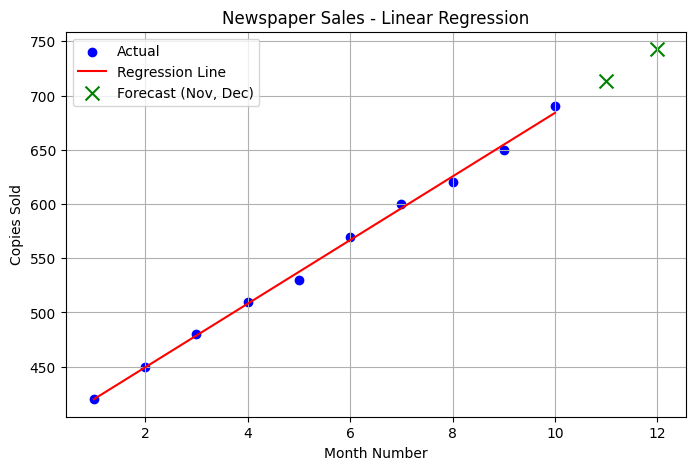

In [ ]:
"""
Linear Regression Model - Newspaper Sales Dataset
Predicts copies sold based on month number
"""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# ----------------------------
# 1. Dataset
# ----------------------------
data = {
    "Month": ["Jan","Feb","March","April","May","June","July","Aug","Sep","Oct"],
    "MonthNo": [1,2,3,4,5,6,7,8,9,10],
    "CopiesSold": [420,450,480,510,530,570,600,620,650,690]
}
df = pd.DataFrame(data)

X = df[["MonthNo"]].values   # feature (2D)
y = df["CopiesSold"].values  # target

# ----------------------------
# 2. Fit Linear Regression Model
# ----------------------------
model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]

print(f"Regression Equation: CopiesSold = {intercept:.2f} + {slope:.2f} * MonthNo")

# ----------------------------
# 3. Evaluate Model
# ----------------------------
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R-squared: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

# ----------------------------
# 4. Forecast future months (Nov, Dec)
# ----------------------------
future_months = np.array([[11],[12]])
future_pred = model.predict(future_months)
for m, p in zip([11,12], future_pred):
    print(f"Month {m} (predicted CopiesSold): {p:.4f}")

# ----------------------------
# 5. Plot
# ----------------------------
plt.figure(figsize=(8,5))
plt.scatter(df["MonthNo"], df["CopiesSold"], color="blue", label="Actual")
plt.plot(df["MonthNo"], y_pred, color="red", label="Regression Line")
plt.scatter([11,12], future_pred, color="green", marker="x", s=100, label="Forecast (Nov, Dec)")
plt.xlabel("Month Number")
plt.ylabel("Copies Sold")
plt.title("Newspaper Sales - Linear Regression")
plt.legend()
plt.grid(True)
plt.show()